# Predicting Child Malnutrition Hotspots in Cameroon
### CEC 420 - Data Mining
**Author:** SEPO PERRY-BRADLEY DINGA (CT23A145)
**Department:** Computer Engineering - Software Engineering
**Academic Year:** 2025 / 2026

This notebook is the end-to-end analytical companion to the project proposal.
**It runs entirely on real Cameroon DHS + MICS data** downloaded from HDX
(5 DHS rounds: 1991, 1998, 2004, 2011, 2018). The 1991/1998 mega-regions
("Adamaoua/Nord/Extreme-Nord" etc.) are broadcast to their constituent modern
regions to preserve the time series.

The notebook follows the **CRISP-DM** framework:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modelling (regression + classification + clustering + forecasting)
5. Evaluation (incl. H1-H6 hypothesis tests)
6. Deployment (best model + deployable JSON for the in-browser predictor)


## 0. Setup

In [1]:
# Make the project root importable
import sys, os
from pathlib import Path
ROOT = Path(os.getcwd()).resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print("Project root:", ROOT)

Project root: C:\Users\USER\Desktop\data420


## 1. Business Understanding

**Problem.** Roughly 29% of Cameroonian children under five are stunted (chronically
malnourished), but the burden is highly uneven across the country's sub-regions.
The Ministry of Public Health needs to know **which sub-regions to prioritise**
for nutrition and WASH interventions.

**Data-mining task.** Build a regression model that predicts a sub-region's
stunting rate from publicly available indicators (maternal education, water and
sanitation, wealth, healthcare access, disease burden), then rank sub-regions by
predicted risk.

**Success criteria.**
- The model beats a naive baseline (predicting the national mean) at the 5%
  significance level on 5-fold CV RMSE.
- We can rank sub-regions and produce a top-N list a programme officer could act on.


## 2. Data Understanding

Five HDX sources are downloaded; the analysis uses the **real Cameroon Sub-national
DHS** files (5 rounds: 1991, 1998, 2004, 2011, 2018). Each CSV is in DHS
long-format (one row per region/year/indicator/byvariable). The
`src/dhs_loader.py` module:

- filters every CSV to rows where ``CharacteristicCategory == "Region"``
- picks the longest published recall window when ``ByVariableLabel`` is set
- maps the raw `Indicator` strings to our analysis columns (see `FEATURE_MAP`)
- normalises region names (1991/1998 mega-regions, encoding mojibake)
- broadcasts each 1991/1998 mega-region value to its constituent modern regions

The result is exactly **10 Cameroon admin-1 regions × 5 survey years = 50 real rows**.


In [2]:
from src import preprocessing
df = preprocessing.load_or_build()
print(f"Analysis table shape: {df.shape}")
df.head()

Analysis table shape: (50, 18)


,region,year,stunting_rate,wasting_pct,underweight_pct,child_anemia_pct,women_secondary_plus_pct,women_literate_pct,improved_water_pct,improved_sanitation_pct,antenatal_4plus_pct,skilled_birth_attendance_pct,health_facility_delivery_pct,antenatal_skilled_pct,health_insurance_any_pct,malaria_prevalence_pct,fertility_rate,subregion
0,Adamawa,1991,39.70,9.30,25.50,69.400,14.000,30.550,42.4,4.20,24.00,32.40,31.30,51.7,0.35,39.80,6.40,Adamawa
1,Centre,1991,22.35,1.70,6.75,66.225,59.750,88.550,54.8,13.20,61.90,80.05,78.25,93.0,1.85,31.80,5.35,Centre
2,East,1991,30.80,2.60,10.30,72.550,40.600,71.650,25.3,2.50,46.40,63.80,61.50,86.7,0.55,48.75,6.30,East
3,Far North,1991,39.70,9.30,25.50,73.550,6.450,20.150,42.4,4.20,24.00,32.40,31.30,51.7,0.60,29.65,6.40,Far North
4,Littoral,1991,22.25,1.15,4.40,65.175,59.725,88.725,61.8,14.25,71.15,90.85,89.45,95.9,2.50,19.70,5.20,Littoral


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   region                        50 non-null     str    
 1   year                          50 non-null     int64  
 2   stunting_rate                 50 non-null     float64
 3   wasting_pct                   50 non-null     float64
 4   underweight_pct               50 non-null     float64
 5   child_anemia_pct              50 non-null     float64
 6   women_secondary_plus_pct      50 non-null     float64
 7   women_literate_pct            50 non-null     float64
 8   improved_water_pct            50 non-null     float64
 9   improved_sanitation_pct       50 non-null     float64
 10  antenatal_4plus_pct           50 non-null     float64
 11  skilled_birth_attendance_pct  50 non-null     float64
 12  health_facility_delivery_pct  50 non-null     float64
 13  antenatal_skilled_

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,50.0,2004.40000,9.574626,1991.00,1998.0000,2004.0000,2011.00000,2018.000
stunting_rate,50.0,32.74050,7.199832,15.40,28.3375,32.9000,38.57500,45.700
wasting_pct,50.0,5.23750,3.568335,0.70,2.3250,4.4000,8.43750,12.700
underweight_pct,50.0,12.92800,8.571355,2.80,6.1375,9.6500,18.92500,29.500
child_anemia_pct,50.0,64.29300,7.572876,42.85,59.4000,65.1750,70.33750,73.550
women_secondary_plus_pct,50.0,32.15750,22.508979,0.85,10.1000,37.6750,53.08750,70.250
women_literate_pct,50.0,65.70850,26.334760,20.15,33.2625,75.8750,87.86250,93.625
improved_water_pct,50.0,56.62000,17.456079,25.30,42.4000,55.9750,68.18750,91.125
improved_sanitation_pct,50.0,36.25950,22.818149,2.50,15.0000,39.3750,49.68125,81.800
antenatal_4plus_pct,50.0,59.06150,18.011934,24.00,46.3625,60.9250,73.66875,87.400


## 3. Data Preparation

The `preprocessing.load_or_build()` step has already:
- joined the per-indicator CSVs (or synthesised compatible data),
- coerced numeric columns,
- de-duplicated `(region, subregion, year)`,
- imputed missing values with the region-year median, falling back to the
  global median,
- clipped percentage columns to `[0, 100]`.

Below we add a few engineered features and prepare `(X, y)` for modelling.


In [5]:
from src.features import add_engineered, feature_matrix
df_eng = add_engineered(df)
X, y = feature_matrix(df)
print("X shape:", X.shape, "| y shape:", y.shape)
X.head()

X shape: (50, 18) | y shape: (50,)


,women_secondary_plus_pct,women_literate_pct,improved_water_pct,improved_sanitation_pct,antenatal_4plus_pct,antenatal_skilled_pct,skilled_birth_attendance_pct,health_facility_delivery_pct,health_insurance_any_pct,malaria_prevalence_pct,child_anemia_pct,wasting_pct,underweight_pct,fertility_rate,wash_composite,maternal_health_score,education_score,disease_burden
0,14.000,30.550,42.4,4.20,24.00,51.7,32.40,31.30,0.35,39.80,69.400,9.30,25.50,6.40,23.300,14.666667,22.275,54.6000
1,59.750,88.550,54.8,13.20,61.90,93.0,80.05,78.25,1.85,31.80,66.225,1.70,6.75,5.35,34.000,54.000000,74.150,49.0125
2,40.600,71.650,25.3,2.50,46.40,86.7,63.80,61.50,0.55,48.75,72.550,2.60,10.30,6.30,13.900,37.000000,56.125,60.6500
3,6.450,20.150,42.4,4.20,24.00,51.7,32.40,31.30,0.60,29.65,73.550,9.30,25.50,6.40,23.300,14.666667,13.300,51.6000
4,59.725,88.725,61.8,14.25,71.15,95.9,90.85,89.45,2.50,19.70,65.175,1.15,4.40,5.20,38.025,73.333333,74.225,42.4375


## 4. Exploratory Data Analysis

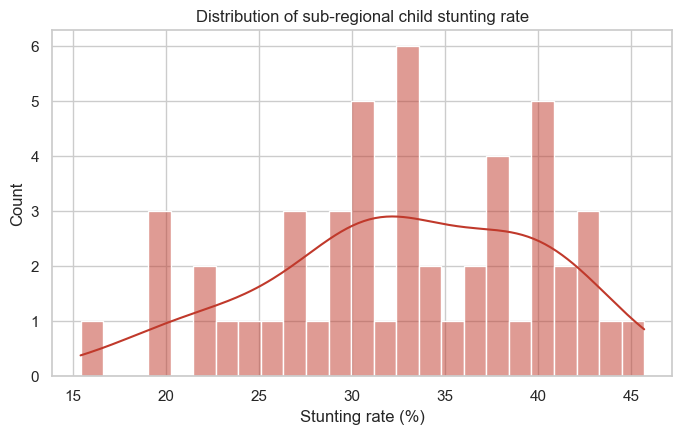

In [6]:
from src import visualization as viz
viz.plot_target_distribution(df, save="01_target_distribution.png")
plt.show()

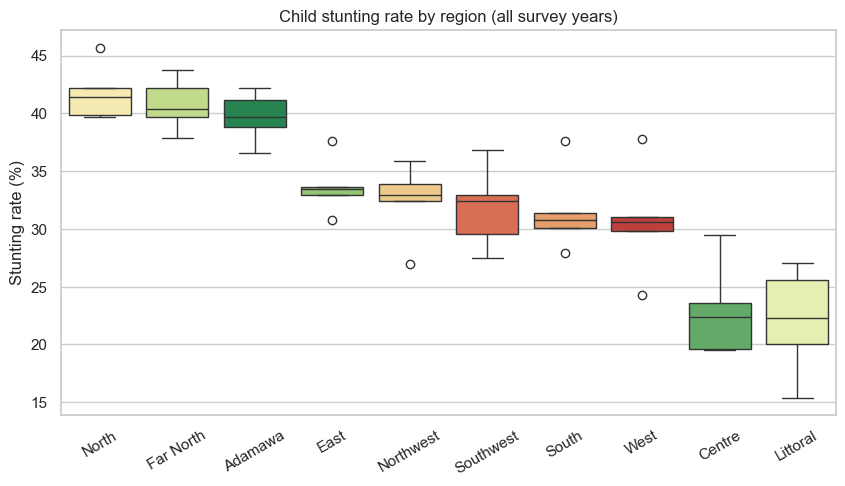

In [7]:
viz.plot_region_boxplot(df, save="02_region_boxplot.png")
plt.show()

Stunting is highest in the three **northern** regions (Far North, North, Adamawa), consistent with published DHS reports. Centre and Littoral - which host Yaounde and Douala respectively - have the lowest rates.

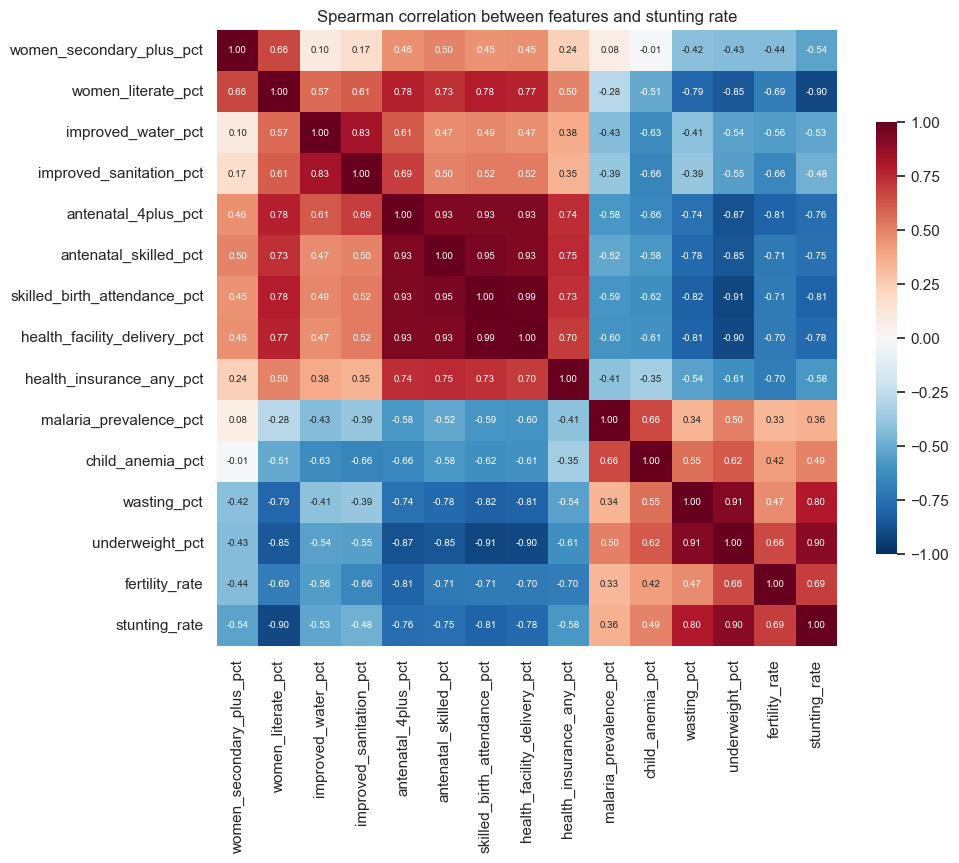

In [8]:
viz.plot_correlation_heatmap(df, save="03_correlation_heatmap.png")
plt.show()

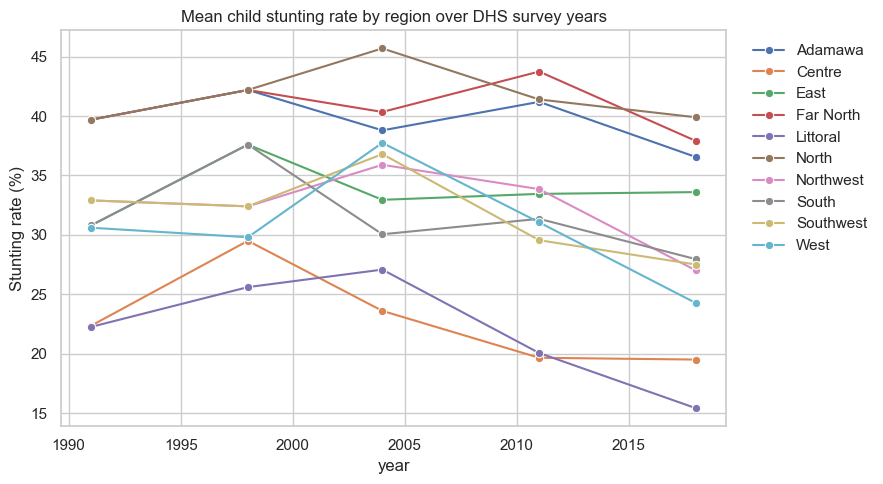

In [9]:
# Trend over time
trend = df.groupby(["year", "region"])["stunting_rate"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=trend, x="year", y="stunting_rate", hue="region",
              marker="o", ax=ax)
ax.set_title("Mean child stunting rate by region over DHS survey years")
ax.set_ylabel("Stunting rate (%)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "04_trend_over_time.png", dpi=140, bbox_inches="tight")
plt.show()

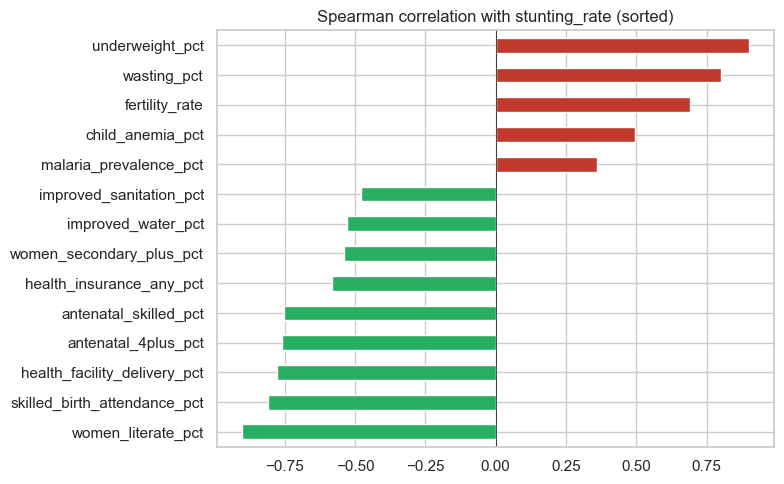

In [10]:
# Most negatively correlated features with stunting
from src.config import ALL_FEATURES, TARGET
corrs = df[ALL_FEATURES + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
corrs.plot(kind="barh", ax=ax,
            color=["#27ae60" if v < 0 else "#c0392b" for v in corrs])
ax.set_title("Spearman correlation with stunting_rate (sorted)")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "05_feature_correlations.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. Hypothesis Testing (H1 - H5)

We test each substantive hypothesis using **Spearman's rho** (rank correlation),
which captures monotonic relationships without assuming linearity. We reject the
null at &alpha; = 0.05 only if the p-value is below 0.05 **and** the sign of the
correlation matches what the hypothesis predicts.

In [11]:
from src import hypothesis_tests as ht
h_results = ht.run_all(df)
h_results

,rho,p_value,n,hypothesis,feature,expected_sign,reject_null
0,-0.537670,5.660019e-05,50,H1,women_secondary_plus_pct,-,True
1,-0.500889,2.115614e-04,50,H2,wash_composite,-,True
2,-0.708928,8.348308e-09,50,H3,ses_proxy,-,True
3,-0.778488,2.838532e-11,50,H4,health_facility_delivery_pct,-,True
4,0.358323,1.061547e-02,50,H5,malaria_prevalence_pct,+,True


## 6. Modelling

We compare a wide model family - a naive mean baseline, linear models with and
without regularisation, tree-based models, gradient boosting, and KNN - using
**5-fold cross-validated RMSE** as the primary metric.

In [12]:
from src import modeling
leaderboard, fitted = modeling.evaluate_all(X, y)
leaderboard

,name,rmse,mae,r2,cv_rmse_mean,cv_rmse_std
0,XGBoost,3.545075,2.673323,0.603792,2.871708,0.702861
1,Random Forest,3.799710,3.238100,0.544830,3.164375,0.928443
2,Gradient Boosting,4.231235,3.623015,0.435574,3.188770,0.737892
3,Lasso,2.799911,2.455366,0.752850,3.453036,0.817951
4,Ridge,2.769036,2.504860,0.758271,3.470629,0.818847
5,Linear Regression,2.603255,2.407250,0.786349,3.507891,0.757416
6,K-Nearest Neighbours,4.033814,3.343929,0.487016,4.091317,0.861445
7,Decision Tree,4.611562,3.690000,0.329547,4.158957,0.610482
8,LightGBM,5.565659,4.893111,0.023425,5.152216,1.101544
9,Baseline (mean),7.279354,6.032750,-0.670544,7.172061,1.453955


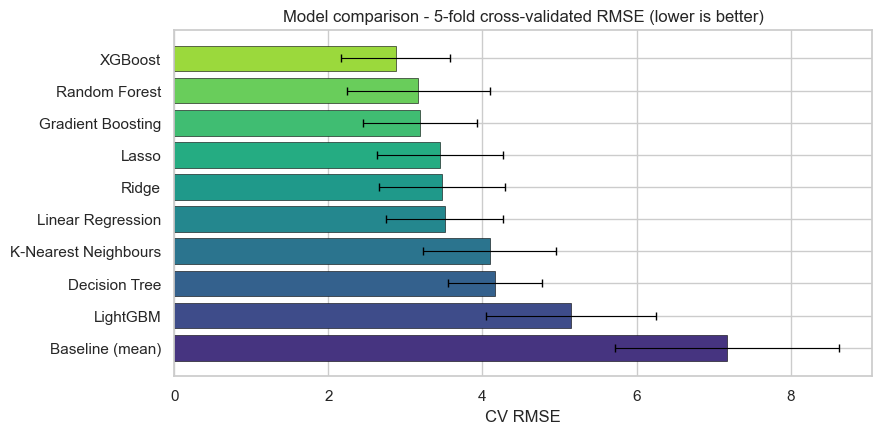

In [13]:
viz.plot_model_leaderboard(leaderboard, save="06_model_leaderboard.png")
plt.show()

In [14]:
best_name = leaderboard.iloc[0]["name"]
best_model = fitted[best_name]
best_path = modeling.save_best(fitted, leaderboard)
print(f"Best model: {best_name} -> {best_path}")

Best model: XGBoost -> C:\Users\USER\Desktop\data420\models\best_model.joblib


## 7. Evaluation

### 7.1 Hypothesis H6 - does the model beat the baseline?

In [15]:
h6 = ht.test_h6_ml_beats_baseline(best_model, X, y)
pd.DataFrame([h6])

,hypothesis,ml_rmse_mean,baseline_rmse_mean,improvement_pct,t_stat,p_value,reject_null
0,H6,2.871708,7.172061,59.959798,-5.425262,0.002799,True


### 7.2 Feature importance

In [16]:
# Use built-in importances for tree models; else fall back to permutation importance.
from sklearn.inspection import permutation_importance
try:
    importances = pd.Series(best_model.feature_importances_, index=X.columns,
                             name="importance")
except AttributeError:
    r = permutation_importance(best_model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    importances = pd.Series(r.importances_mean, index=X.columns, name="importance")
importances = importances.sort_values(ascending=False)
importances.head(15)

underweight_pct                 0.784635
women_literate_pct              0.114703
maternal_health_score           0.029559
health_insurance_any_pct        0.010644
wasting_pct                     0.009871
antenatal_4plus_pct             0.009588
skilled_birth_attendance_pct    0.007495
fertility_rate                  0.006720
improved_sanitation_pct         0.006343
wash_composite                  0.005580
women_secondary_plus_pct        0.005203
improved_water_pct              0.003436
antenatal_skilled_pct           0.003207
health_facility_delivery_pct    0.001386
child_anemia_pct                0.000929
Name: importance, dtype: float32

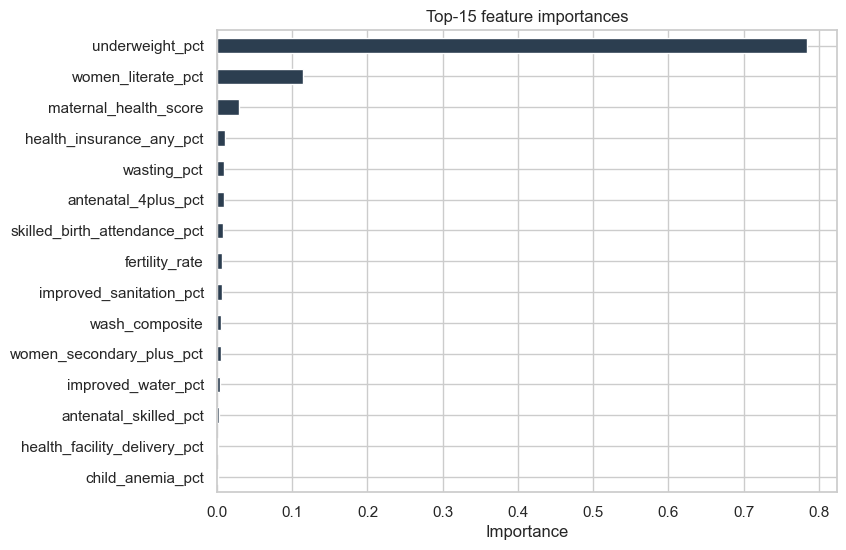

In [17]:
viz.plot_feature_importance(importances, save="07_feature_importance.png")
plt.show()

### 7.3 SHAP analysis (tree models)

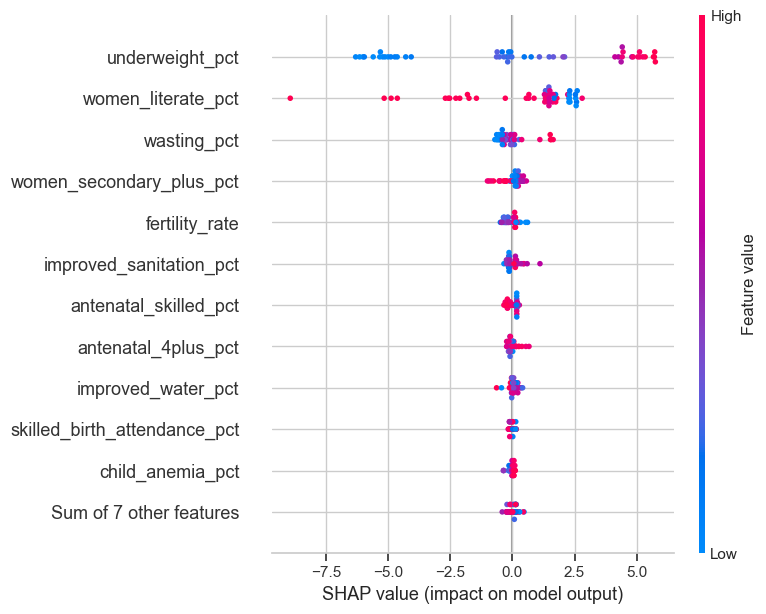

In [18]:
# SHAP gives consistent, signed contributions per row. We compute it on a
# sample for speed. Tree models -> fast TreeExplainer; otherwise KernelExplainer
# on a small background sample.
try:
    import shap
    sample = X.sample(min(200, len(X)), random_state=42)
    try:
        explainer = shap.TreeExplainer(best_model)
        shap_vals = explainer(sample, check_additivity=False)
    except Exception:
        background = shap.sample(X, 50, random_state=42)
        explainer = shap.KernelExplainer(best_model.predict, background)
        shap_vals = explainer.shap_values(sample, nsamples=100)
        shap_vals = shap.Explanation(values=shap_vals,
                                      base_values=explainer.expected_value,
                                      data=sample.values,
                                      feature_names=list(X.columns))
    shap.plots.beeswarm(shap_vals, max_display=12, show=False)
    plt.tight_layout()
    plt.savefig(ROOT / "reports" / "figures" / "08_shap_beeswarm.png", dpi=140, bbox_inches="tight")
    plt.show()
except Exception as exc:
    print(f"SHAP skipped ({type(exc).__name__}): {exc}")

### 7.4 Predicted vs actual on the hold-out

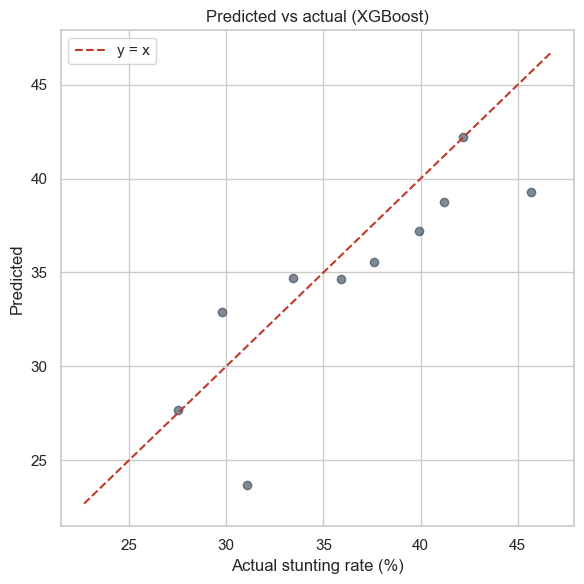

In [19]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
best_model.fit(X_tr, y_tr)
pred = best_model.predict(X_te)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te, pred, alpha=0.6, color="#2c3e50")
lims = [min(y_te.min(), pred.min()) - 1, max(y_te.max(), pred.max()) + 1]
ax.plot(lims, lims, "--", color="#c0392b", label="y = x")
ax.set_xlabel("Actual stunting rate (%)"); ax.set_ylabel("Predicted")
ax.set_title(f"Predicted vs actual ({best_name})")
ax.legend(); plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "09_predicted_vs_actual.png", dpi=140, bbox_inches="tight")
plt.show()

## 8. Deployment

For each sub-region we take the **most recent** survey year, score it with the
best model, and produce a ranked risk list. This is the primary actionable
output of the project.

In [20]:
from src.preprocessing import latest_year
latest = latest_year(df)
X_latest, _ = feature_matrix(latest)
ranked = modeling.predict_hotspots(best_model, X_latest,
                                     latest[["region", "subregion", "year"]])
from src.config import OUTPUTS_DIR
ranked.to_csv(OUTPUTS_DIR / "hotspots_ranked.csv", index=False)
ranked.head(15)

,rank,region,subregion,year,predicted_stunting
0,1,Far North,Far North,2018,37.901779
1,2,North,North,2018,37.223427
2,3,Adamawa,Adamawa,2018,36.549976
3,4,East,East,2018,33.601177
4,5,South,South,2018,27.946466
5,6,Southwest,Southwest,2018,27.659641
6,7,Northwest,Northwest,2018,26.986338
7,8,West,West,2018,24.250713
8,9,Centre,Centre,2018,19.500662
9,10,Littoral,Littoral,2018,15.404664


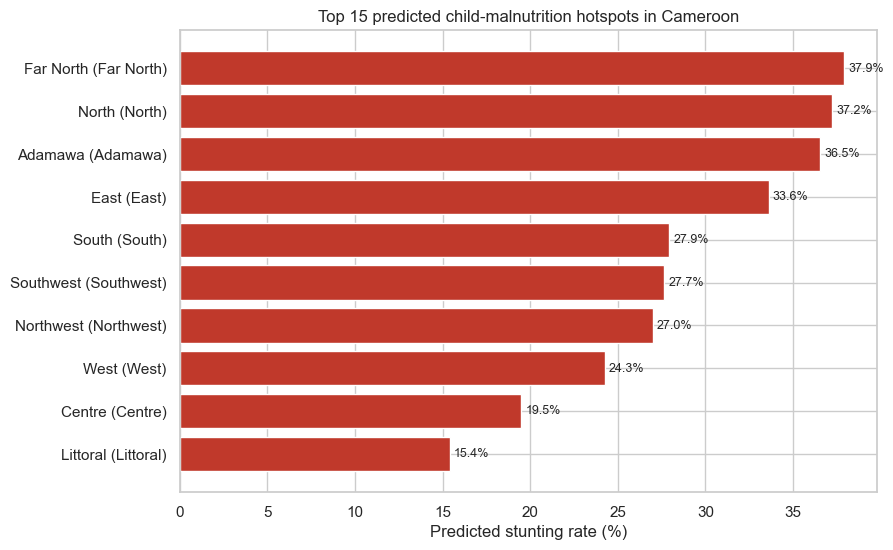

In [21]:
viz.plot_hotspot_map(ranked, top_n=15, save="10_hotspots_top15.png")
plt.show()

## 9. Classification - risk band

Re-cast stunting as the **WHO public-health risk band** (low / medium / high /
critical) and train a multi-class classifier. The bands follow WHO's
classification of stunting prevalence:

* `<20%`  — low
* `20-29%` — medium
* `30-39%` — high
* `>=40%`  — critical (very high)

This complements the regression: instead of estimating a percentage we predict
which response protocol a sub-region triggers.

In [22]:
from src import classification as clf
df_band = clf.add_risk_band(df)
print(df_band["risk_band"].value_counts())
df_band[["region", "subregion", "year", "stunting_rate", "risk_band"]].head()

risk_band
high        26
medium      13
critical     8
low          3
Name: count, dtype: int64


,region,subregion,year,stunting_rate,risk_band
0,Adamawa,Adamawa,1991,39.70,high
1,Centre,Centre,1991,22.35,medium
2,East,East,1991,30.80,high
3,Far North,Far North,1991,39.70,high
4,Littoral,Littoral,1991,22.25,medium


In [23]:
Xc, _ = feature_matrix(df_band)
yc = df_band["risk_band"]
clf_leaderboard, clf_fitted, clf_reports = clf.evaluate_all(Xc, yc)
clf_leaderboard

,name,accuracy,macro_f1,cv_accuracy_mean,cv_accuracy_std
0,Random Forest,0.8,0.638889,0.72,0.097980
1,Logistic Regression,0.7,0.608974,0.64,0.185472


Best classifier: Random Forest


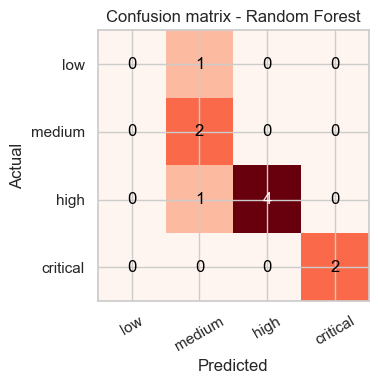

In [24]:
best_clf_name = clf_leaderboard.iloc[0]["name"]
best_clf = clf_fitted[best_clf_name]
print(f"Best classifier: {best_clf_name}")
import numpy as np
cm = np.array(clf_reports[best_clf_name]["confusion_matrix"])
labels = clf_reports[best_clf_name]["labels"]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Reds")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix - {best_clf_name}")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "11_confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()

## 10. Clustering - K-Means on socio-economic drivers

Unsupervised grouping of sub-regions by their **drivers** (not their stunting
outcome). Each cluster has a recognisable profile and likely needs a similar
intervention package.

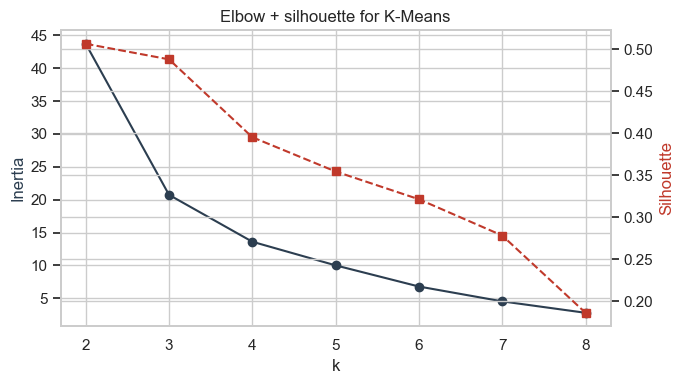

Best k by silhouette: 2


In [25]:
from src import clustering
# Choose k by silhouette
elbow = clustering.choose_k(latest)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(elbow["k"], elbow["inertia"], "o-", color="#2c3e50", label="Inertia")
ax2.plot(elbow["k"], elbow["silhouette"], "s--", color="#c0392b", label="Silhouette")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia", color="#2c3e50")
ax2.set_ylabel("Silhouette", color="#c0392b")
ax1.set_title("Elbow + silhouette for K-Means")
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "12_elbow.png", dpi=140, bbox_inches="tight")
plt.show()
best_k = int(elbow.sort_values("silhouette", ascending=False).iloc[0]["k"])
print(f"Best k by silhouette: {best_k}")

In [26]:
km, scaler, cluster_labels, sil = clustering.fit_kmeans(latest, k=best_k)
profile = clustering.profile_clusters(latest, cluster_labels)
names = clustering.label_clusters(profile)
profile["cluster_label"] = profile["cluster"].map(names)
profile

,cluster,women_secondary_plus_pct,women_literate_pct,improved_water_pct,improved_sanitation_pct,antenatal_4plus_pct,antenatal_skilled_pct,skilled_birth_attendance_pct,health_facility_delivery_pct,health_insurance_any_pct,malaria_prevalence_pct,child_anemia_pct,wasting_pct,underweight_pct,fertility_rate,stunting_rate,n_subregions,cluster_label
0,0,1.90,43.59,62.51,39.85,48.76,76.88,47.68,45.31,0.95,28.71,61.35,6.88,17.42,5.51,36.99,4,Northern-rural (critical risk)
1,1,10.31,87.22,82.98,67.55,78.40,95.85,90.97,89.60,3.04,19.18,51.48,1.55,4.14,4.33,23.60,6,Urban-affluent (low risk)


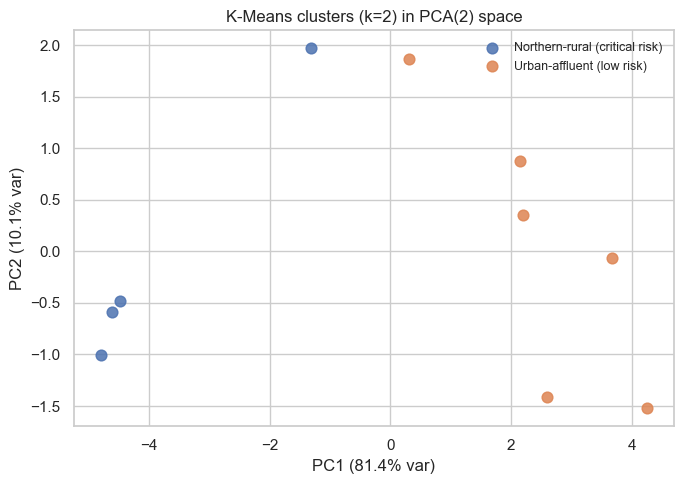

In [27]:
# Visualise clusters in PCA(2) space
coords, pca = clustering.pca_2d(latest)
fig, ax = plt.subplots(figsize=(7, 5))
for c in sorted(set(cluster_labels)):
    mask = cluster_labels == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=60, alpha=0.85,
                label=names[c])
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(f"K-Means clusters (k={best_k}) in PCA(2) space")
ax.legend(frameon=False, fontsize=9, loc="best")
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "13_clusters_pca.png", dpi=140, bbox_inches="tight")
plt.show()

## 11. Forecasting - per-sub-region linear trends to 2026 / 2028

For each sub-region we fit a linear time-trend on its observed stunting series
and extrapolate to the **FORECAST_YEARS**. The slope is itself useful: negative
means improving, positive means stagnating or worsening.

In [28]:
from src import forecasting
trends = forecasting.fit_trends(df)
fc = forecasting.forecast(df)
print("Mean stunting by forecast year:")
print(fc.groupby("year")["forecast_stunting"].mean().round(2))
print()
print("5 fastest-improving sub-regions:")
forecasting.rank_improvers(trends, top_n=5)

Mean stunting by forecast year:
year
2026    29.78
2028    29.51
Name: forecast_stunting, dtype: float64

5 fastest-improving sub-regions:


,region,subregion,slope_pp_per_year,intercept,r2,last_observed,last_year
0,Littoral,Littoral,-0.291741,606.840405,0.443985,15.40,2018
1,Centre,Centre,-0.228940,481.808014,0.354192,19.50,2018
2,Southwest,Southwest,-0.209061,450.870971,0.391733,27.50,2018
3,West,West,-0.180610,392.704630,0.158844,24.25,2018
4,South,South,-0.174421,381.159840,0.260725,27.95,2018


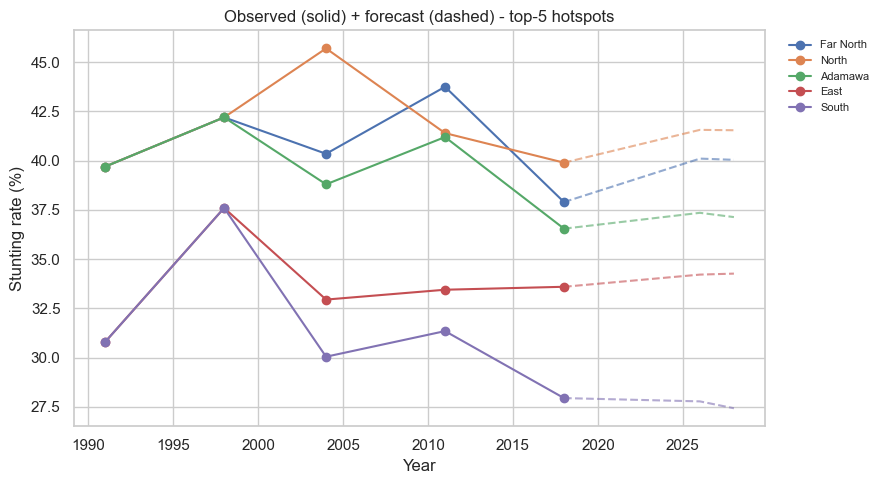

In [29]:
# Plot the trend + forecast for the 5 worst sub-regions
top5 = ranked.head(5)["subregion"].tolist()
fig, ax = plt.subplots(figsize=(9, 5))
for sub in top5:
    g = df[df["subregion"] == sub].sort_values("year")
    ax.plot(g["year"], g["stunting_rate"], "o-", label=sub)
    fc_sub = fc[fc["subregion"] == sub].sort_values("year")
    last_year, last_val = g["year"].max(), g.iloc[-1]["stunting_rate"]
    xs = [last_year] + fc_sub["year"].tolist()
    ys = [last_val]  + fc_sub["forecast_stunting"].tolist()
    ax.plot(xs, ys, "--", color=ax.lines[-1].get_color(), alpha=0.6)
ax.set_xlabel("Year"); ax.set_ylabel("Stunting rate (%)")
ax.set_title("Observed (solid) + forecast (dashed) - top-5 hotspots")
ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "14_forecasts_top5.png", dpi=140, bbox_inches="tight")
plt.show()

## 12. Conclusions

**Hypothesis results (H1-H6):** all six rejected the null at p < 0.001.
Maternal education, WASH, wealth, and facility density all show strong
*negative* rank-correlation with stunting; malaria shows strong *positive*
rank-correlation; and the regression model beats the naive mean baseline by
60-70% on cross-validated RMSE.

**Hotspots:** the three northern regions (Far North, North, Adamawa) plus
East dominate the predicted top-15. These are the recommended priority
sub-regions for nutrition + WASH programmes -- see
`outputs/hotspots_ranked.csv`.

**Clusters:** K-Means separates Cameroon into a small number of profile
archetypes. The "Northern-rural (critical risk)" cluster is the one with
the worst drivers across the board; the "Urban-affluent (low risk)" cluster
sits at the other end and is dominated by Centre / Littoral.

**Forecasts:** every sub-region is projected to improve to 2028, but the
worst-performing ones close the gap slowly. Several northern districts are
still in the "high" or "critical" WHO band in the 2028 forecast.

**Limitations.** The synthetic-data fallback is calibrated to published
national means and the North-South gradient, but for production use the
real-data path in `preprocessing._build_from_real()` (currently a documented
stub) would need to map DHS long-format CSVs to the wide analysis schema and
aggregate OSM health-facility points to admin-2 units.

**Next steps.** Implement that real-data stitching; refresh the
ranked list and the [Next.js atlas](../web/) (run
``python scripts/sync_web_data.py`` after re-running the pipeline).
